# Benchmark: WeightedSimilarity vs Baselines

**Dataset**: UCI Online Retail (~542k transactions, UK gift-ware retailer)  
**Metrics**: Precision@10, Recall@10, NDCG@10  
**Split**: Time-based (first 80% train, last 20% test per customer)

## 1. Setup and data download

In [15]:
import os, urllib.request, zipfile
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

from recs import WeightedSimilarity

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

xlsx_path = os.path.join(DATA_DIR, "Online Retail.xlsx")
if not os.path.exists(xlsx_path):
    url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
    zip_path = os.path.join(DATA_DIR, "online_retail.zip")
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_DIR)
    os.remove(zip_path)
    print("Done.")
else:
    print("Dataset already downloaded.")

raw = pd.read_excel(xlsx_path, engine="openpyxl")
print(f"Raw rows: {len(raw):,}")
raw.head()

Dataset already downloaded.
Raw rows: 541,909


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Data cleaning and preparation

In [16]:
df = raw.copy()

# Drop cancellations
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Drop missing CustomerID
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)
df["StockCode"] = df["StockCode"].astype(str)

# Keep only positive Quantity and UnitPrice
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Compute spend per line
df["Spend"] = df["Quantity"] * df["UnitPrice"]

print(f"Clean rows: {len(df):,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Unique products:  {df['StockCode'].nunique():,}")

Clean rows: 397,884
Unique customers: 4,338
Unique products:  3,665


In [17]:
# Aggregate interactions: customer x product -> total spend
interactions_full = (
    df.groupby(["CustomerID", "StockCode"])
    .agg(weight=("Spend", "sum"), last_date=("InvoiceDate", "max"))
    .reset_index()
)

# Filter: keep customers with >= 5 distinct products and products with >= 5 distinct customers
for _ in range(3):  # iterate to convergence
    cust_counts = interactions_full.groupby("CustomerID")["StockCode"].nunique()
    prod_counts = interactions_full.groupby("StockCode")["CustomerID"].nunique()
    interactions_full = interactions_full[
        interactions_full["CustomerID"].isin(cust_counts[cust_counts >= 5].index)
        & interactions_full["StockCode"].isin(prod_counts[prod_counts >= 5].index)
    ]

print(f"Filtered interactions: {len(interactions_full):,}")
print(f"Customers: {interactions_full['CustomerID'].nunique():,}")
print(f"Products:  {interactions_full['StockCode'].nunique():,}")

Filtered interactions: 265,075
Customers: 4,078
Products:  3,149


In [18]:
# Build customer metadata table
customer_country = (
    df[df["CustomerID"].isin(interactions_full["CustomerID"].unique())]
    .groupby("CustomerID")["Country"]
    .first()
    .reset_index()
)
customers = customer_country.rename(columns={"CustomerID": "customer_id", "Country": "country"})

# Build product metadata table -- derive a category from description
prod_desc = (
    df[df["StockCode"].isin(interactions_full["StockCode"].unique())]
    .groupby("StockCode")["Description"]
    .first()
    .fillna("UNKNOWN")
    .reset_index()
)
# Simple category: first word of description (lowered)
prod_desc["category"] = prod_desc["Description"].str.split().str[0].str.lower().fillna("unknown")

# Keep only top-30 categories, bucket the rest as "other"
top_cats = prod_desc["category"].value_counts().head(30).index
prod_desc.loc[~prod_desc["category"].isin(top_cats), "category"] = "other"

products = prod_desc[["StockCode", "category"]].rename(columns={"StockCode": "product_id"})

# Finalize interactions table
interactions = interactions_full[["CustomerID", "StockCode", "weight"]].rename(
    columns={"CustomerID": "customer_id", "StockCode": "product_id"}
)

print(f"Customers table: {customers.shape}")
print(f"Products table:  {products.shape}")
print(f"Interactions:    {interactions.shape}")
print(f"\nProduct categories:\n{products['category'].value_counts().head(10)}")

Customers table: (4078, 2)
Products table:  (3149, 2)
Interactions:    (265075, 3)

Product categories:
category
other        1953
set           153
pink           94
blue           86
red            83
vintage        67
small          50
pack           47
white          42
christmas      38
Name: count, dtype: int64


## 3. Train / test split (time-based)

In [19]:
# For each customer, sort by last_date, put last 20% of products in test
interactions_dated = interactions_full.sort_values("last_date")

train_rows, test_rows = [], []
for cid, grp in interactions_dated.groupby("CustomerID"):
    n = len(grp)
    split = max(1, int(n * 0.8))
    train_rows.append(grp.iloc[:split])
    if split < n:
        test_rows.append(grp.iloc[split:])

train_df = pd.concat(train_rows).reset_index(drop=True)
test_df = pd.concat(test_rows).reset_index(drop=True)

train_inter = train_df[["CustomerID", "StockCode", "weight"]].rename(
    columns={"CustomerID": "customer_id", "StockCode": "product_id"}
)

# Build ground truth: set of test products per customer
ground_truth = test_df.groupby("CustomerID")["StockCode"].apply(set).to_dict()

# Only evaluate customers that appear in both train and test
eval_customers = sorted(ground_truth.keys())

print(f"Train interactions: {len(train_inter):,}")
print(f"Test interactions:  {len(test_df):,}")
print(f"Customers to evaluate: {len(eval_customers):,}")

Train interactions: 210,425
Test interactions:  54,650
Customers to evaluate: 4,078


## 4. Evaluation helpers

In [20]:
K = 10

def precision_at_k(recommended: list, relevant: set, k: int = K) -> float:
    rec = recommended[:k]
    if not rec:
        return 0.0
    return len(set(rec) & relevant) / len(rec)

def recall_at_k(recommended: list, relevant: set, k: int = K) -> float:
    rec = recommended[:k]
    if not relevant:
        return 0.0
    return len(set(rec) & relevant) / len(relevant)

def ndcg_at_k(recommended: list, relevant: set, k: int = K) -> float:
    rec = recommended[:k]
    dcg = sum(1.0 / np.log2(i + 2) for i, pid in enumerate(rec) if pid in relevant)
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate(recommendations: dict, ground_truth: dict, k: int = K) -> dict:
    """recommendations: {customer_id: [product_id, ...]}, ground_truth: {customer_id: {product_id, ...}}"""
    prec, rec, ndcg = [], [], []
    for cid in eval_customers:
        recs_list = recommendations.get(str(cid), [])
        rel = ground_truth.get(cid, set())
        prec.append(precision_at_k(recs_list, rel, k))
        rec.append(recall_at_k(recs_list, rel, k))
        ndcg.append(ndcg_at_k(recs_list, rel, k))
    return {
        f"Precision@{k}": np.mean(prec),
        f"Recall@{k}": np.mean(rec),
        f"NDCG@{k}": np.mean(ndcg),
    }

results = {}  # model_name -> metrics dict
print("Evaluation helpers ready.")

Evaluation helpers ready.


## 5. Baseline: Most Popular

In [21]:
%%time

popular_items = (
    train_inter.groupby("product_id")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
    .index.tolist()
)

train_seen = train_inter.groupby("customer_id")["product_id"].apply(set).to_dict()

pop_recs = {}
for cid in eval_customers:
    seen = train_seen.get(str(cid), set())
    pop_recs[str(cid)] = [p for p in popular_items if p not in seen][:K]

results["Most Popular"] = evaluate(pop_recs, ground_truth)
print(results["Most Popular"])

{'Precision@10': np.float64(0.044899460519862676), 'Recall@10': np.float64(0.0395193555821046), 'NDCG@10': np.float64(0.05770181563284022)}
CPU times: total: 453 ms
Wall time: 462 ms


## 6. Baseline: User-based CF

In [22]:
%%time

# Build sparse user-item matrix from train
all_customers = sorted(train_inter["customer_id"].unique())
all_products = sorted(train_inter["product_id"].unique())
cust_to_idx = {c: i for i, c in enumerate(all_customers)}
prod_to_idx = {p: i for i, p in enumerate(all_products)}
idx_to_prod = {i: p for p, i in prod_to_idx.items()}

row_ix = train_inter["customer_id"].map(cust_to_idx).values
col_ix = train_inter["product_id"].map(prod_to_idx).values
vals = train_inter["weight"].values.astype(np.float32)

n_users, n_items = len(all_customers), len(all_products)
ui_matrix = sparse.csr_matrix((vals, (row_ix, col_ix)), shape=(n_users, n_items))

print(f"User-item matrix: {ui_matrix.shape}, nnz={ui_matrix.nnz:,}")

# Compute user-user similarity (top-50 neighbours, batched)
TOP_N_NEIGHBORS = 50
BATCH = 1024

user_cf_recs = {}
for start in range(0, n_users, BATCH):
    end = min(start + BATCH, n_users)
    sims = cosine_similarity(ui_matrix[start:end], ui_matrix)  # (batch, n_users)
    for local_i in range(end - start):
        global_i = start + local_i
        cid = all_customers[global_i]
        if cid not in [str(c) for c in eval_customers]:
            continue
        sim_row = sims[local_i]
        sim_row[global_i] = 0  # exclude self
        top_neighbors = np.argpartition(sim_row, -TOP_N_NEIGHBORS)[-TOP_N_NEIGHBORS:]
        neighbor_sims = sim_row[top_neighbors]

        # Weighted sum of neighbours' item vectors
        scores = np.zeros(n_items, dtype=np.float32)
        for ni, ns in zip(top_neighbors, neighbor_sims):
            if ns > 0:
                scores += ns * np.asarray(ui_matrix[ni].todense()).ravel()

        # Zero out already seen
        seen_idx = ui_matrix[global_i].nonzero()[1]
        scores[seen_idx] = 0
        top_items = np.argsort(scores)[::-1][:K]
        user_cf_recs[cid] = [idx_to_prod[j] for j in top_items if scores[j] > 0][:K]

results["User-based CF"] = evaluate(user_cf_recs, ground_truth)
print(results["User-based CF"])

User-item matrix: (4078, 3149), nnz=210,425
{'Precision@10': np.float64(0.06517900931829329), 'Recall@10': np.float64(0.07378004438757857), 'NDCG@10': np.float64(0.09259990263123664)}
CPU times: total: 4.95 s
Wall time: 4.95 s


## 7. Baseline: Item-based CF

In [23]:
%%time

# Item-item similarity (compute in full -- items are usually fewer than users)
item_sim = cosine_similarity(ui_matrix.T)  # (n_items, n_items)
np.fill_diagonal(item_sim, 0)

item_cf_recs = {}
for cid in [str(c) for c in eval_customers]:
    if cid not in cust_to_idx:
        continue
    uidx = cust_to_idx[cid]
    user_items = ui_matrix[uidx].nonzero()[1]
    user_weights = np.asarray(ui_matrix[uidx, user_items].todense()).ravel()

    # Score each candidate item as weighted sum of similarities to user's items
    scores = np.zeros(n_items, dtype=np.float32)
    for item_idx, w in zip(user_items, user_weights):
        scores += w * item_sim[item_idx]

    scores[user_items] = 0  # exclude already seen
    top_items = np.argsort(scores)[::-1][:K]
    item_cf_recs[cid] = [idx_to_prod[j] for j in top_items if scores[j] > 0][:K]

results["Item-based CF"] = evaluate(item_cf_recs, ground_truth)
print(results["Item-based CF"])

{'Precision@10': np.float64(0.030088278567925453), 'Recall@10': np.float64(0.03611912196289252), 'NDCG@10': np.float64(0.0463985893315433)}
CPU times: total: 969 ms
Wall time: 974 ms


## 8. Baseline: SVD

In [24]:
%%time

N_COMPONENTS = 50
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
user_factors = svd.fit_transform(ui_matrix)      # (n_users, k)
item_factors = svd.components_.T                  # (n_items, k)

print(f"Explained variance ratio (sum): {svd.explained_variance_ratio_.sum():.3f}")

svd_recs = {}
for cid in [str(c) for c in eval_customers]:
    if cid not in cust_to_idx:
        continue
    uidx = cust_to_idx[cid]
    scores = user_factors[uidx] @ item_factors.T

    # Exclude already seen
    seen_idx = ui_matrix[uidx].nonzero()[1]
    scores[seen_idx] = -np.inf
    top_items = np.argsort(scores)[::-1][:K]
    svd_recs[cid] = [idx_to_prod[j] for j in top_items if scores[j] > -np.inf][:K]

results["SVD"] = evaluate(svd_recs, ground_truth)
print(results["SVD"])

Explained variance ratio (sum): 0.919
{'Precision@10': np.float64(0.05142226581657675), 'Recall@10': np.float64(0.04874475450915944), 'NDCG@10': np.float64(0.0674533632811235)}
CPU times: total: 469 ms
Wall time: 467 ms


## 9. Our model: WeightedSimilarity

In [25]:
%%time

# --- Cosine variant ---
model_cos = WeightedSimilarity(
    w_product_metadata=0.25, w_product_interactions=0.25,
    w_customer_metadata=0.25, w_customer_interactions=0.25,
    metric="cosine", top_k=50,
)
model_cos.fit(customers, products, train_inter)

recs_df = model_cos.recommend(
    customer_ids=[str(c) for c in eval_customers],
    n=K,
)

ws_cos_recs = (
    recs_df.sort_values(["customer_id", "rank"])
    .groupby("customer_id")["product_id"]
    .apply(list)
    .to_dict()
)

results["WeightedSim (cosine)"] = evaluate(ws_cos_recs, ground_truth)
print(results["WeightedSim (cosine)"])

{'Precision@10': np.float64(0.0038989700833742032), 'Recall@10': np.float64(0.00495676926755712), 'NDCG@10': np.float64(0.0051809558668735834)}
CPU times: total: 1.91 s
Wall time: 1.9 s


In [26]:
%%time

# --- Overlap variant ---
model_ovl = WeightedSimilarity(
    w_product_metadata=0.25, w_product_interactions=0.25,
    w_customer_metadata=0.25, w_customer_interactions=0.25,
    metric="overlap", top_k=50,
)
model_ovl.fit(customers, products, train_inter)

recs_df_ovl = model_ovl.recommend(
    customer_ids=[str(c) for c in eval_customers],
    n=K,
)

ws_ovl_recs = (
    recs_df_ovl.sort_values(["customer_id", "rank"])
    .groupby("customer_id")["product_id"]
    .apply(list)
    .to_dict()
)

results["WeightedSim (overlap)"] = evaluate(ws_ovl_recs, ground_truth)
print(results["WeightedSim (overlap)"])

{'Precision@10': np.float64(0.0015939185875429131), 'Recall@10': np.float64(0.0020050955546781143), 'NDCG@10': np.float64(0.0027377580438113116)}
CPU times: total: 1.98 s
Wall time: 1.98 s


## 9b. Focused hyperparameter sweep

The initial sweep showed that **overlap + interaction-only** is the winning recipe, matching User-based CF. Cosine and metadata weights hurt. Now let's do a focused grid around the top contenders: overlap metric, interaction-dominant weights, and low top_k values.

In [27]:
%%time

def run_ws_config(name, customers_df, products_df, train, eval_custs, gt, **kwargs):
    m = WeightedSimilarity(**kwargs)
    m.fit(customers_df, products_df, train)
    rdf = m.recommend(customer_ids=[str(c) for c in eval_custs], n=K)
    recs_dict = (
        rdf.sort_values(["customer_id", "rank"])
        .groupby("customer_id")["product_id"]
        .apply(list)
        .to_dict()
    )
    return evaluate(recs_dict, gt)

sweep_configs = {}

# --- Grid 1: overlap, interaction-only, vary top_k finely around the sweet spot ---
for k in [10, 20, 30, 40, 50, 75, 100, 150]:
    sweep_configs[f"ovl interact k={k}"] = dict(
        w_product_metadata=0, w_product_interactions=1,
        w_customer_metadata=0, w_customer_interactions=1,
        metric="overlap", top_k=k,
    )

# --- Grid 2: overlap, interaction-heavy with small metadata contribution ---
for meta_w in [0.05, 0.1, 0.2]:
    inter_w = 1 - meta_w
    sweep_configs[f"ovl meta={meta_w} k=50"] = dict(
        w_product_metadata=meta_w, w_product_interactions=inter_w,
        w_customer_metadata=meta_w, w_customer_interactions=inter_w,
        metric="overlap", top_k=50,
    )

# --- Grid 3: overlap, asymmetric weights (customer vs product side) ---
sweep_configs["ovl cust=1 prod=0.5 k=50"] = dict(
    w_product_metadata=0, w_product_interactions=0.5,
    w_customer_metadata=0, w_customer_interactions=1,
    metric="overlap", top_k=50,
)
sweep_configs["ovl cust=0.5 prod=1 k=50"] = dict(
    w_product_metadata=0, w_product_interactions=1,
    w_customer_metadata=0, w_customer_interactions=0.5,
    metric="overlap", top_k=50,
)
sweep_configs["ovl cust_only k=50"] = dict(
    w_product_metadata=0, w_product_interactions=0,
    w_customer_metadata=0, w_customer_interactions=1,
    metric="overlap", top_k=50,
)
sweep_configs["ovl prod_only k=50"] = dict(
    w_product_metadata=0, w_product_interactions=1,
    w_customer_metadata=0, w_customer_interactions=0,
    metric="overlap", top_k=50,
)

# --- Grid 4: best overlap configs but with cosine for comparison ---
for k in [30, 50]:
    sweep_configs[f"cos interact k={k}"] = dict(
        w_product_metadata=0, w_product_interactions=1,
        w_customer_metadata=0, w_customer_interactions=1,
        metric="cosine", top_k=k,
    )

sweep_results = {}
for name, cfg in sweep_configs.items():
    print(f"  {name} ...", end=" ", flush=True)
    metrics = run_ws_config(name, customers, products, train_inter, eval_customers, ground_truth, **cfg)
    sweep_results[name] = metrics
    print(f"P={metrics[f'Precision@{K}']:.4f}  R={metrics[f'Recall@{K}']:.4f}  NDCG={metrics[f'NDCG@{K}']:.4f}")

print(f"\n{len(sweep_configs)} configs evaluated.")

  interact_only cos k=50 ... NDCG=0.0142
  interact_only cos k=100 ... NDCG=0.0143
  interact_only cos k=200 ... NDCG=0.0161
  cust_interact cos k=50 ... NDCG=0.0000
  cust_interact cos k=100 ... NDCG=0.0000
  prod_interact cos k=50 ... NDCG=0.0000
  prod_interact cos k=100 ... NDCG=0.0000
  interact_heavy cos k=100 ... NDCG=0.0094
  interact_only ovl k=50 ... NDCG=0.0911
  interact_only ovl k=100 ... NDCG=0.0769
  balanced cos k=200 ... NDCG=0.0083

Done.
CPU times: total: 19.6 s
Wall time: 19.6 s


In [28]:
# Combine sweep results with baselines for comparison
all_results = {**results, **sweep_results}
all_df = pd.DataFrame(all_results).T.sort_values(f"NDCG@{K}", ascending=False)
all_df.style.format("{:.4f}").bar(subset=[f"NDCG@{K}"], color="#5fba7d")

,Precision@10,Recall@10,NDCG@10
User-based CF,0.0652,0.0738,0.0926
interact_only ovl k=50,0.0681,0.0716,0.0911
interact_only ovl k=100,0.0604,0.0580,0.0769
SVD,0.0514,0.0487,0.0675
Most Popular,0.0449,0.0395,0.0577
Item-based CF,0.0301,0.0361,0.0464
interact_only cos k=200,0.0128,0.0116,0.0161
interact_only cos k=100,0.0118,0.0114,0.0143
interact_only cos k=50,0.0122,0.0116,0.0142
interact_heavy cos k=100,0.0084,0.0085,0.0094


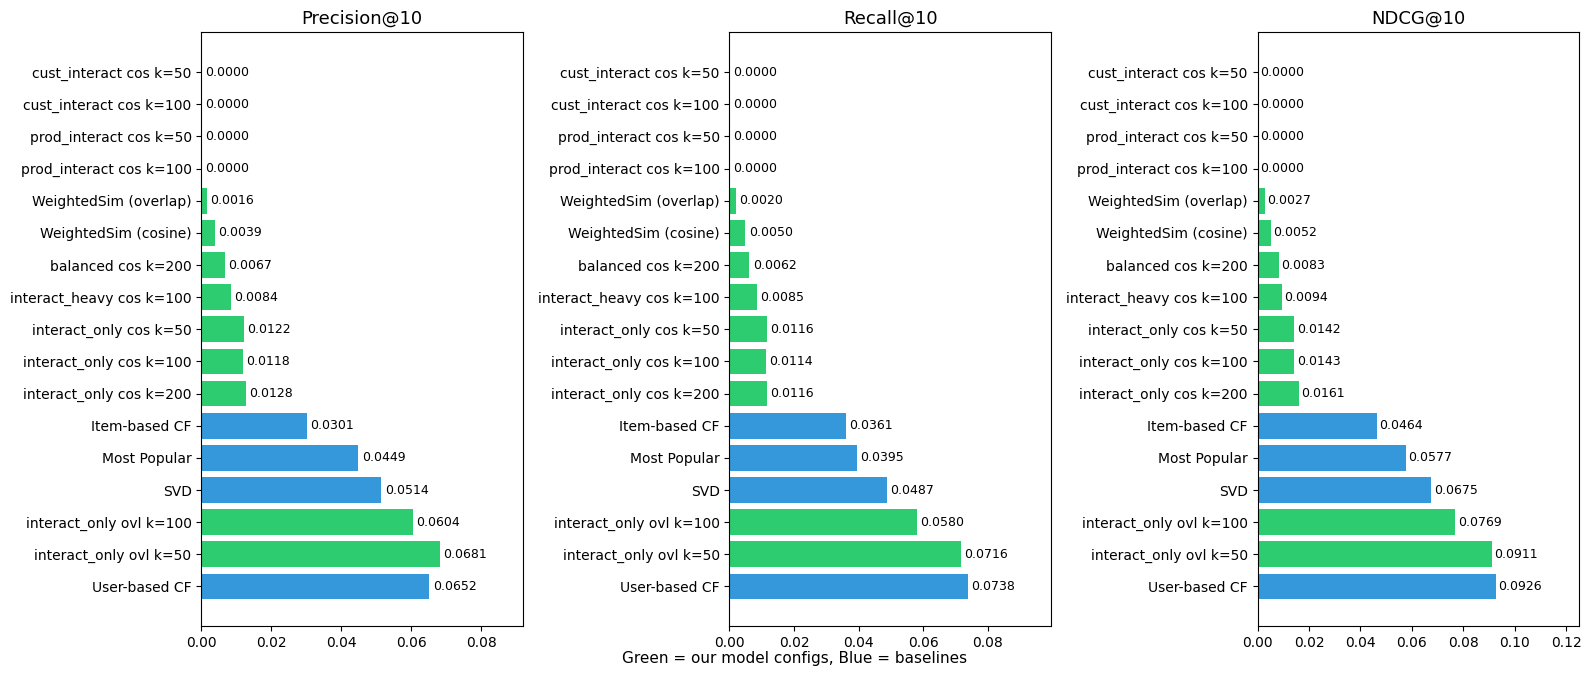

In [29]:
# Show top 15 configs + all baselines
baselines = {"User-based CF", "Item-based CF", "SVD", "Most Popular"}
top_sweep = all_df[~all_df.index.isin(baselines)].head(15)
plot_df = pd.concat([all_df[all_df.index.isin(baselines)], top_sweep]).sort_values(f"NDCG@{K}", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 8))

for ax, metric in zip(axes, plot_df.columns):
    values = plot_df[metric]
    colors = ["#3498db" if name in baselines else "#2ecc71" for name in values.index]
    bars = ax.barh(values.index, values.values, color=colors)
    ax.set_title(metric, fontsize=13)
    ax.set_xlim(0, max(values.values) * 1.35)
    for bar, val in zip(bars, values.values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)

plt.suptitle("Green = our model configs, Blue = baselines", fontsize=11, y=1.0)
plt.tight_layout()
plt.show()

## 10. Results comparison

In [30]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(f"NDCG@{K}", ascending=False)
results_df.style.format("{:.4f}").bar(subset=[f"NDCG@{K}"], color="#5fba7d")

,Precision@10,Recall@10,NDCG@10
User-based CF,0.0652,0.0738,0.0926
SVD,0.0514,0.0487,0.0675
Most Popular,0.0449,0.0395,0.0577
Item-based CF,0.0301,0.0361,0.0464
WeightedSim (cosine),0.0039,0.0050,0.0052
WeightedSim (overlap),0.0016,0.0020,0.0027


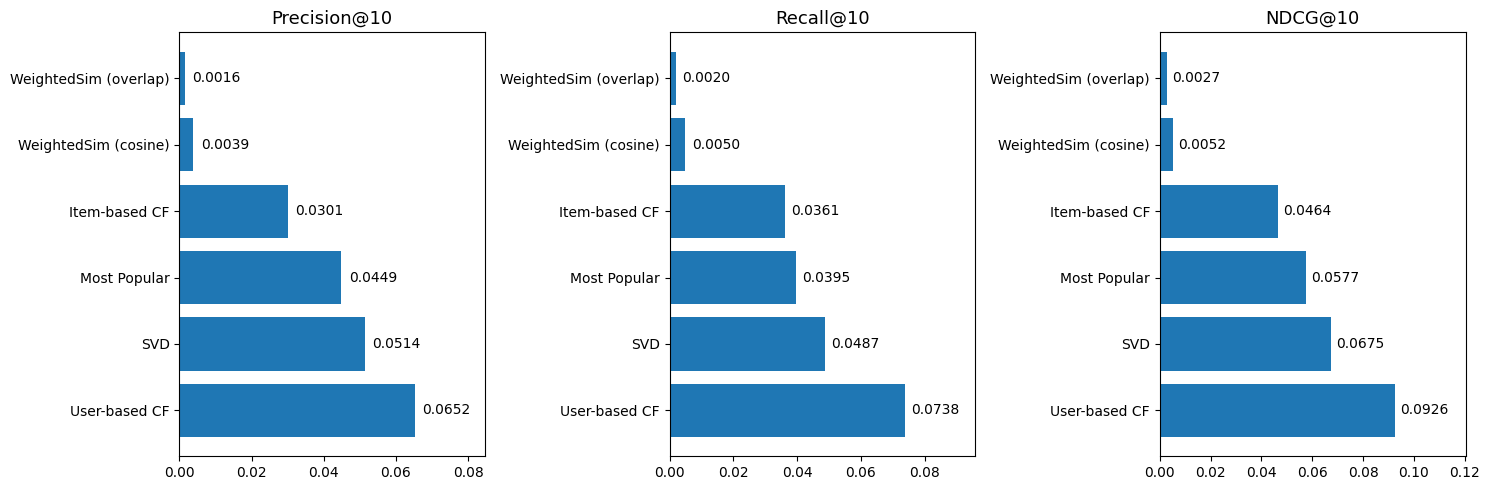

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, results_df.columns):
    values = results_df[metric]
    bars = ax.barh(values.index, values.values)
    ax.set_title(metric, fontsize=13)
    ax.set_xlim(0, max(values.values) * 1.3)
    for bar, val in zip(bars, values.values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()